In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# imports for OLS / Anova
import statsmodels.formula.api as smf
import statsmodels.api as sm

# imports for function
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
# functions

In [4]:
def boxplot_nums(df, cols_lists):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    col_lists_len = len(cols_lists)
    all_lists_len = []
    iter = 0
    for i in cols_lists:
        all_lists_len.append(len(i))
    
    fig, ax  = plt.subplots(1,col_lists_len, gridspec_kw={'width_ratios': all_lists_len})
    
    for i in cols_lists:
        sns.boxplot(data=df[i], ax=ax[iter])
        ax[iter].set_xticklabels(ax[iter].get_xticklabels(),rotation=55)
        iter+=1
    
    plt.show()

In [5]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev
    

  #fig, ax = plt.subplots()
  sns.kdeplot(data[i], shade=True)
    
  max_ax = (sns.kdeplot(data[i]).lines[0].get_xydata())[:, 1].max()
  y_line = [max_ax/100, max_ax/100]
  y_point = [max_ax/100]
    
  sns.lineplot(x = points, y=y_line, color = 'black', label = "std_dev")
  sns.scatterplot(x=[mini,maxi], y=y_line, color = 'orange', label = "min/max")
  sns.scatterplot(x=[mean], y=y_point, color = 'red', label = "mean")
  sns.scatterplot(x=[median], y=y_point, color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [7]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


In [8]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group, width=7, height=5):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (width*size, height), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    #norm_count_readable = str(round(value*100, 1))
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    ax = sns.barplot(x=norm_count, y=norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    #plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))
    plt.title('n_uniques = {}'.format(n_uni))
    var = ax.bar_label(ax.containers[0], rotation=0, padding=2)
    plt.show()

In [9]:
# extract load

In [10]:
ls -lh ./data

Le format du paramŠtre est incorrect - "data".


In [11]:
path = './data/'
csv_path = path + 'clean_openfoodfacts_3.csv'
df = pd.read_csv(csv_path, low_memory=False)

In [12]:
df.rename(columns = {'energy-kcal_100g':'energy_kcal_100g'}, inplace=True)

In [13]:
df.head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,6.7,12.41,One-dish meals,Composite foods
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,6.7,12.41,One-dish meals,Composite foods
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.40,Sweetened beverages,Beverages
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,6.7,12.41,One-dish meals,Composite foods
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,0.1,0.0,10.40,Sweetened beverages,Beverages


In [14]:
df.shape

(46254, 15)

In [15]:
df.describe()

,code,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,4.625400e+04,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000
mean,3.819760e+12,8.816672,7.997487,903.026066,1.030215,0.406654,8.405316,4.261906,1.734880,8.320786,15.305030
std,4.428525e+12,6.760442,8.172165,664.687971,2.218823,0.902549,14.179234,7.071811,3.635696,10.287734,16.857723
min,1.756000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.248830e+12,3.000000,1.500000,347.000000,0.080000,0.031496,0.800000,0.200000,0.000000,2.000000,5.000000
50%,3.329770e+12,9.000000,5.800000,755.000000,0.650000,0.255906,2.900000,1.400000,0.900000,6.700000,12.410000
75%,3.608581e+12,13.000000,12.000000,1400.000000,1.300000,0.511811,10.000000,5.000000,2.100000,7.800000,13.000000
max,3.661112e+14,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [16]:
#missing data
df.isnull().sum()

code                       0
nutrition_grade_fr         0
nutrition-score-fr_100g    0
proteins_100g              0
energy_100g                0
salt_100g                  0
sodium_100g                0
sugars_100g                0
saturated-fat_100g         0
product_name               0
fiber_100g                 0
fat_100g                   0
carbohydrates_100g         0
pnns_groups_2              0
pnns_groups_1              0
dtype: int64

# Univariate analysis

In [17]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46254 entries, 0 to 46253
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   code                     46254 non-null  int64  
 1   nutrition_grade_fr       46254 non-null  object 
 2   nutrition-score-fr_100g  46254 non-null  float64
 3   proteins_100g            46254 non-null  float64
 4   energy_100g              46254 non-null  float64
 5   salt_100g                46254 non-null  float64
 6   sodium_100g              46254 non-null  float64
 7   sugars_100g              46254 non-null  float64
 8   saturated-fat_100g       46254 non-null  float64
 9   product_name             46254 non-null  object 
 10  fiber_100g               46254 non-null  float64
 11  fat_100g                 46254 non-null  float64
 12  carbohydrates_100g       46254 non-null  float64
 13  pnns_groups_2            46254 non-null  object 
 14  pnns_groups_1         

## Numerical variables

In [18]:
df.columns[df.dtypes == 'float64'] 

Index(['nutrition-score-fr_100g', 'proteins_100g', 'energy_100g', 'salt_100g',
       'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g'],
      dtype='object')

In [19]:
num_cols = ['nutrition-score-fr_100g', 'proteins_100g', 'energy_100g', 'salt_100g',
       'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g']
energy_cols = ['energy_100g']
scores_cols = ['nutrition-score-fr_100g']


##

macro_nutrients = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g']
salt = ['salt_100g', 'sodium_100g']

In [20]:
df.dtypes[df.dtypes == 'float64'].size

10

There's 10 numerical variables, that could be split into 3 groups regarding their different units of measurement / orders of magnitude :

- nutrients (less than 100g per 100g)
- energy (less than 900 Cal per 100g)
- nutrition-score

In [21]:
# distributions du data set "cleané"

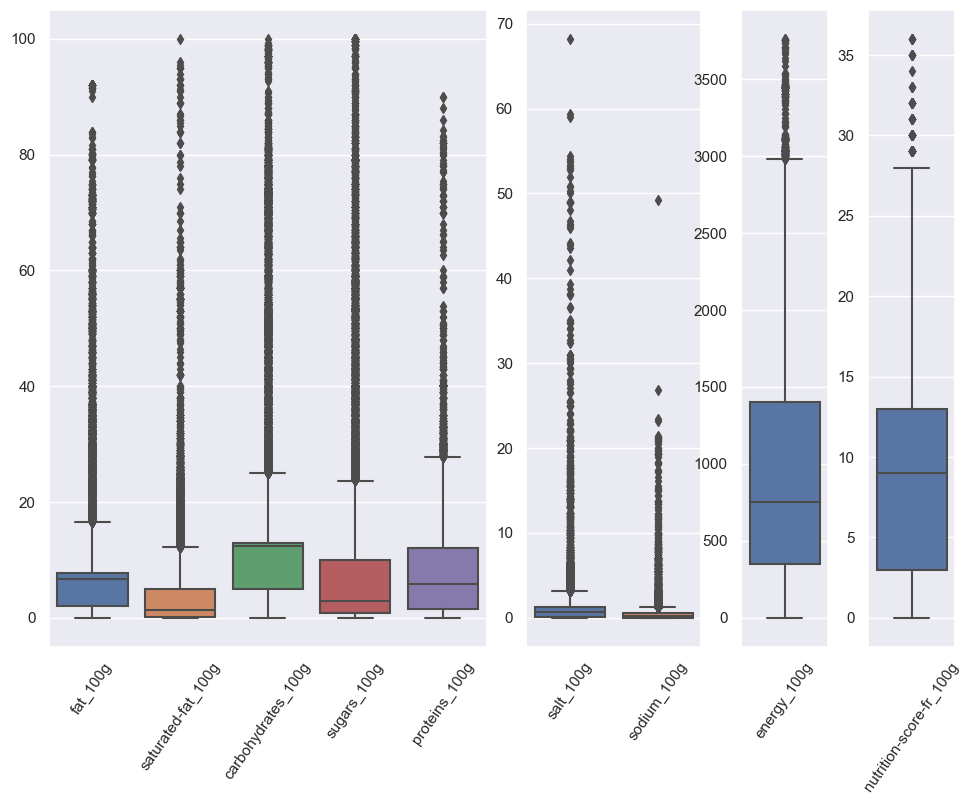

In [22]:
boxplot_nums(df, [macro_nutrients, salt, energy_cols, scores_cols])

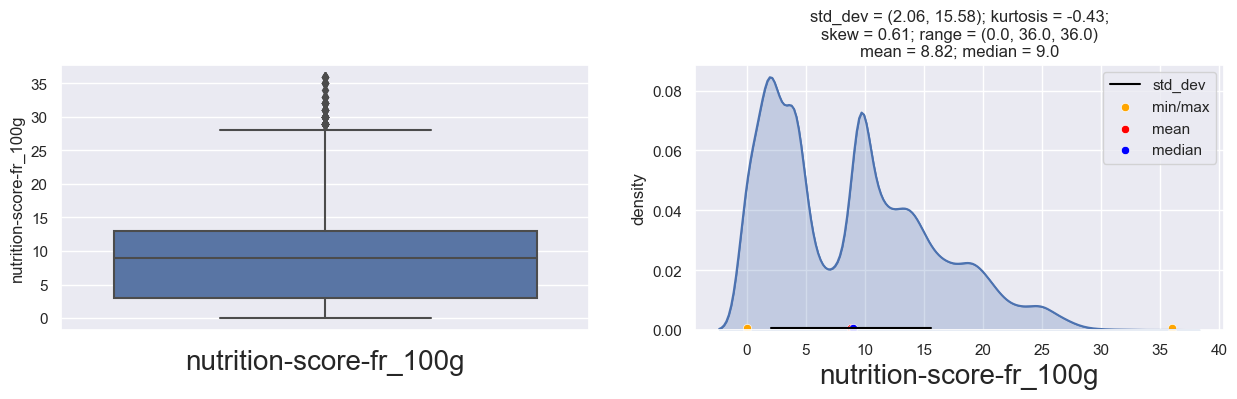

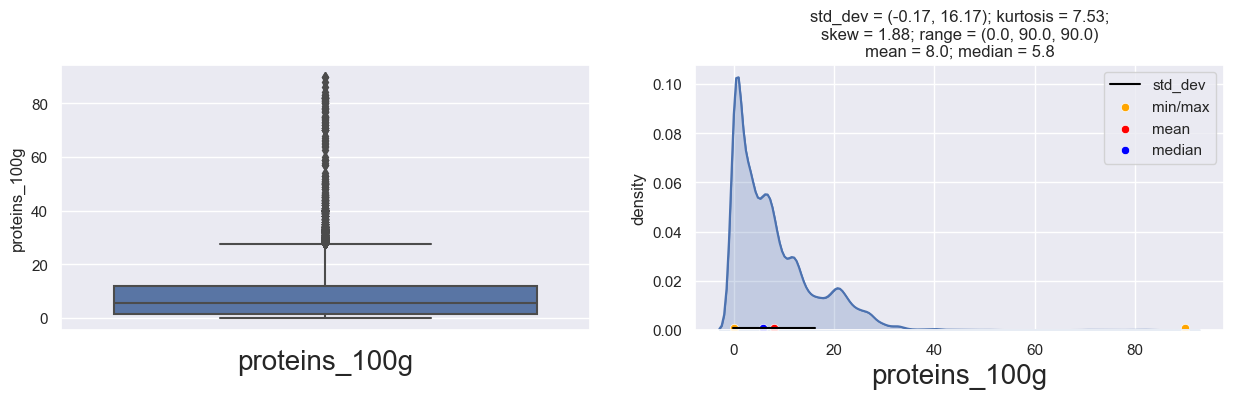

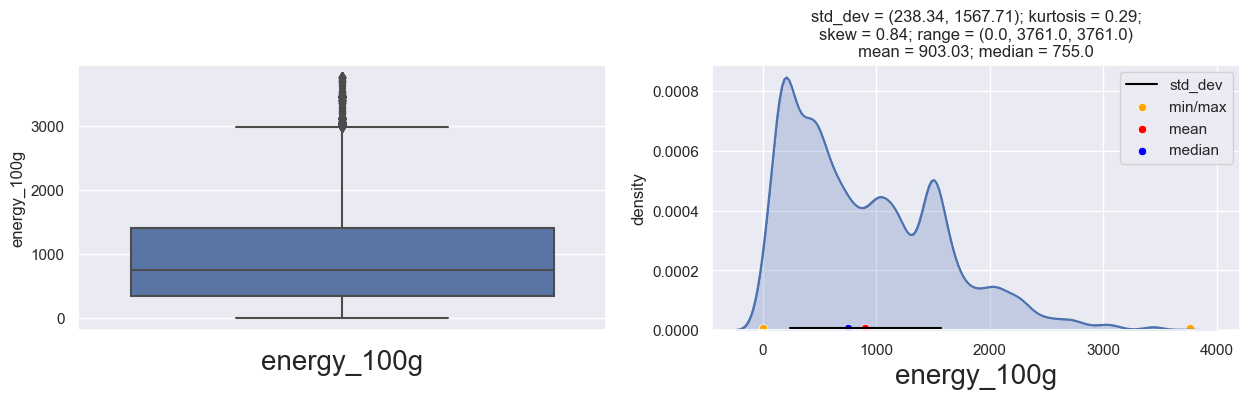

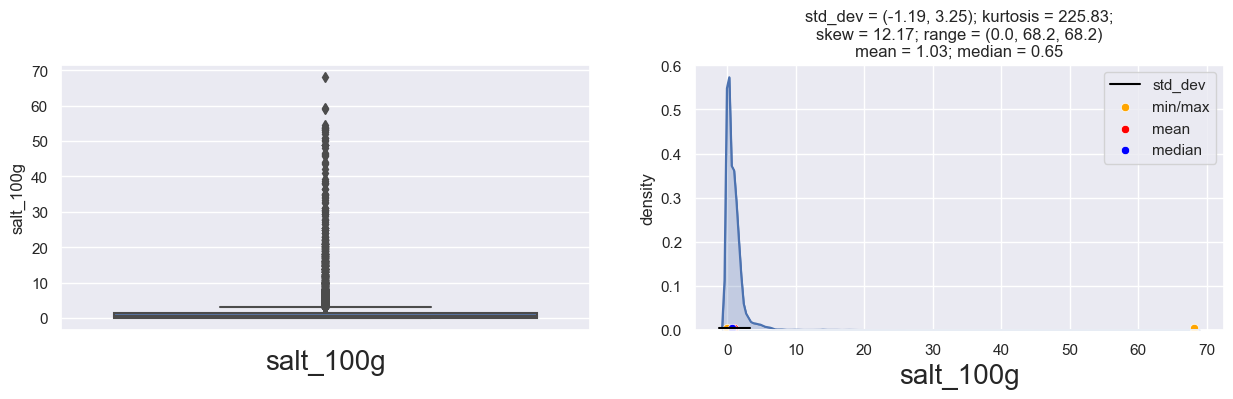

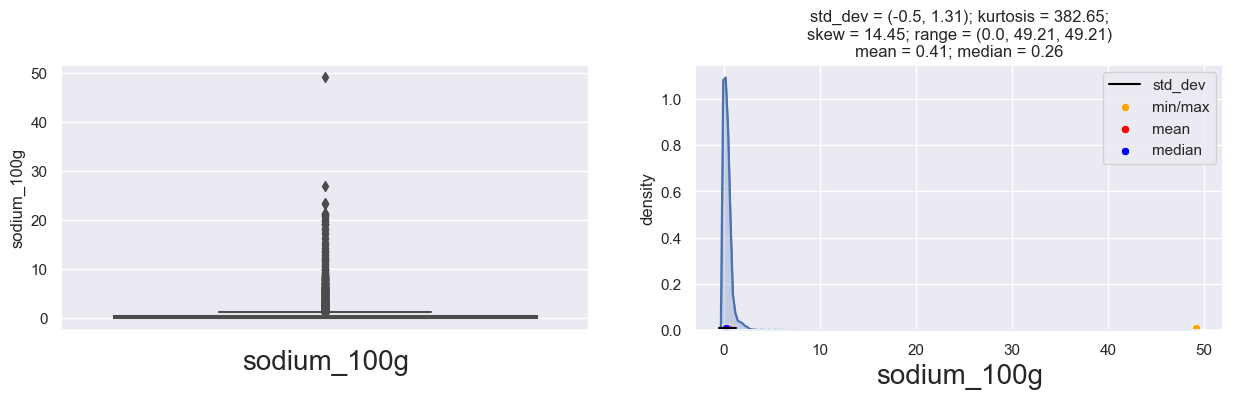

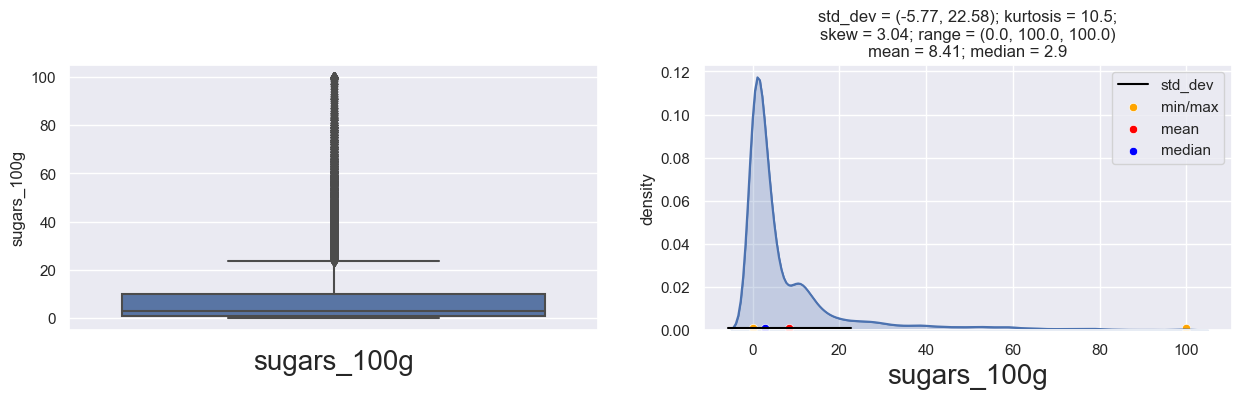

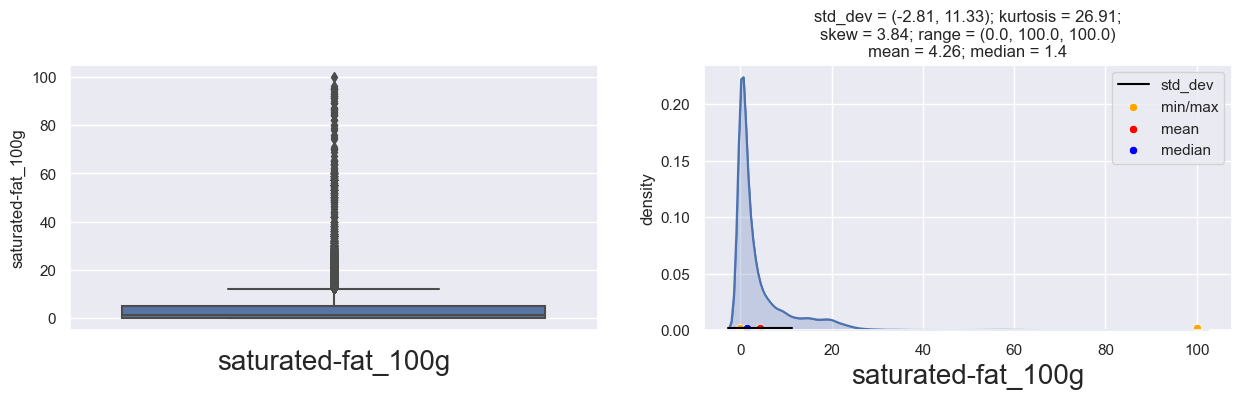

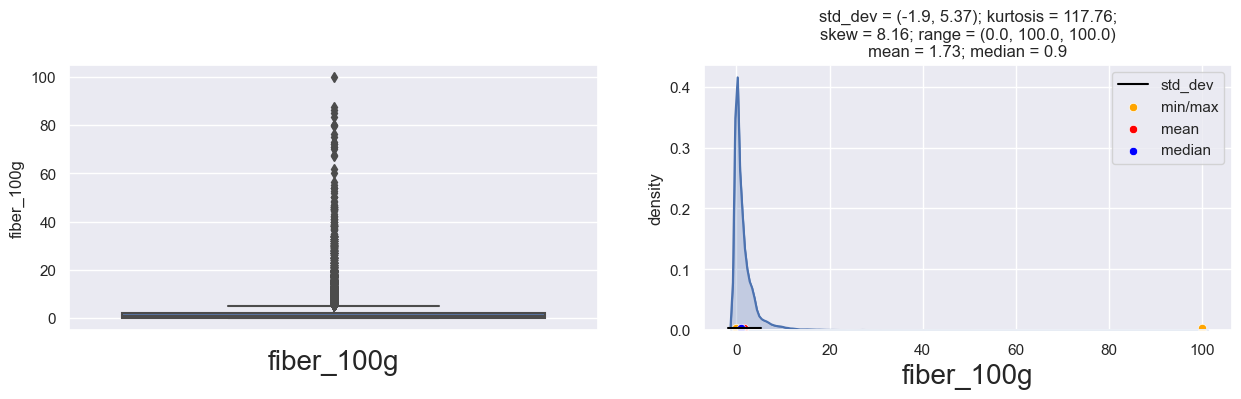

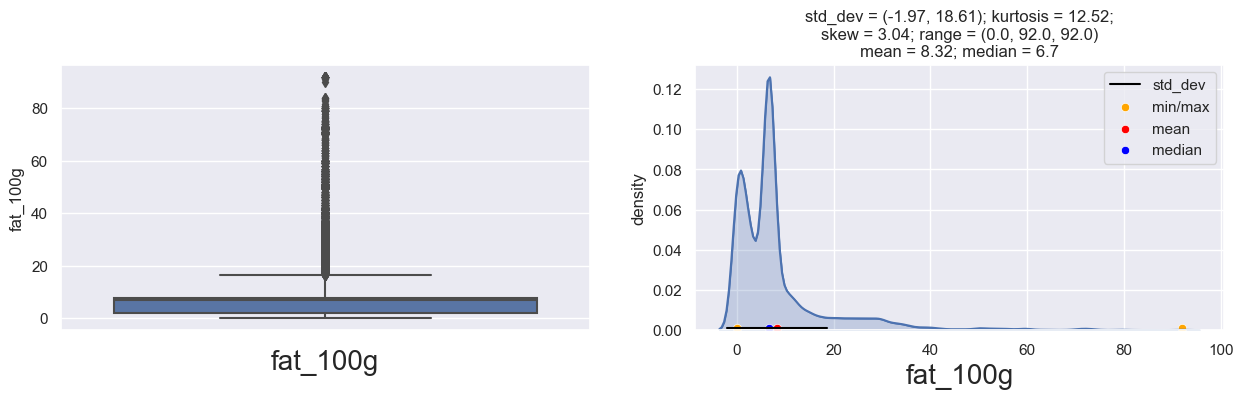

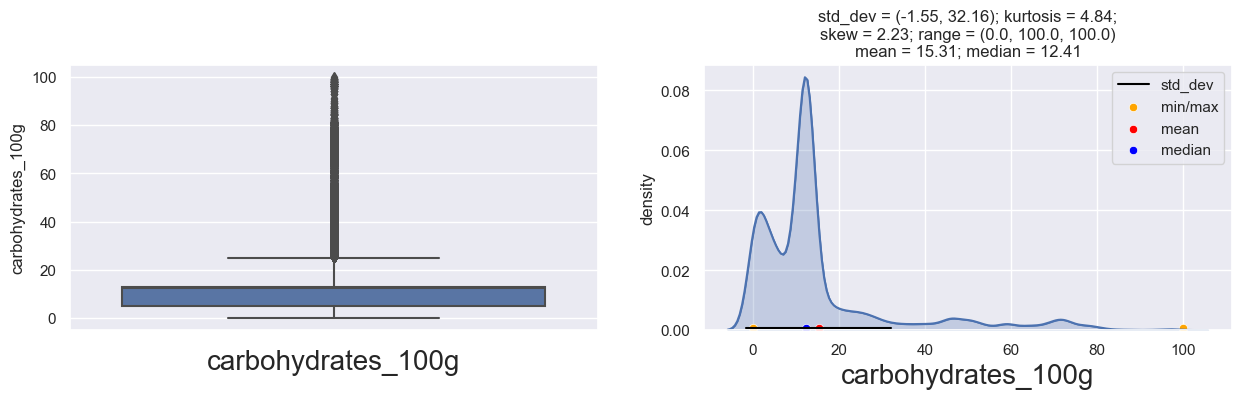

In [23]:
UVA_num_plus(df, num_cols)

### Comparison with univariates from un-cleaned data source

In [24]:
#old_path = path + 'fr.openfoodfacts.org.products.csv'
#columns = ['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
#        'fat_100g', 'saturated-fat_100g',
#       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
#       'sodium_100g']

In [25]:
#df_old = pd.read_csv(old_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

In [26]:
#df_old = df_old[columns]

In [27]:
#df_old.shape

In [28]:
#old_num_cols = df_old.columns[df_old.dtypes == 'float64']
#old_num_cols

In [29]:
# ce sont les distributions du data set initial !!!

#UVA_num_plus(df_old, old_num_cols)

## Categorical variables

In [30]:
df.dtypes[df.dtypes == 'object'].size

4

In [31]:
cat_cols = df.columns[df.dtypes == 'object'].to_list()
cat_cols

['nutrition_grade_fr', 'product_name', 'pnns_groups_2', 'pnns_groups_1']

In [32]:
mylist = df['pnns_groups_1'].unique()
mylist

array(['Composite foods', 'Beverages', 'Fruits and vegetables',
       'Salty snacks', 'Fat and sauces', 'Sugary snacks',
       'Milk and dairy products', 'Cereals and potatoes',
       'Fish Meat Eggs'], dtype=object)

In [33]:
n =10

newlist = mylist[:n]
newlist

array(['Composite foods', 'Beverages', 'Fruits and vegetables',
       'Salty snacks', 'Fat and sauces', 'Sugary snacks',
       'Milk and dairy products', 'Cereals and potatoes',
       'Fish Meat Eggs'], dtype=object)

In [34]:
cats = ['pnns_groups_1', 'pnns_groups_2']

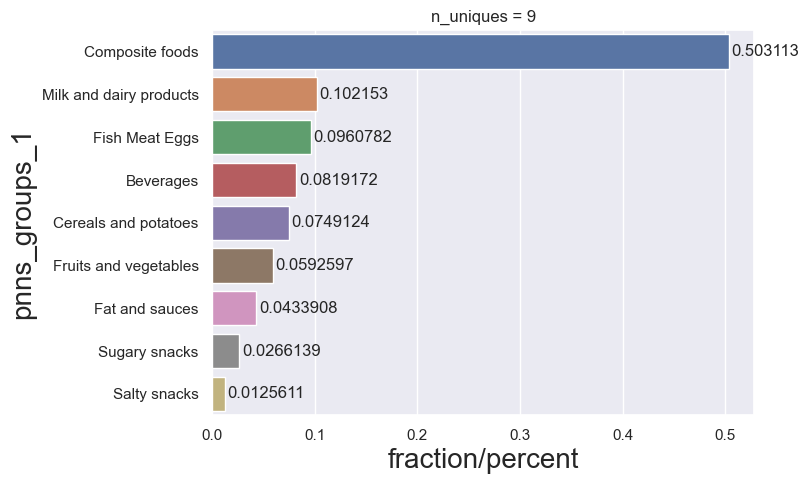

In [35]:
pd.set_option('display.max_rows', 10)
UVA_category(df, ['pnns_groups_1'])

In [36]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
Composite foods            23271
Milk and dairy products     4725
Fish Meat Eggs              4444
Beverages                   3789
Cereals and potatoes        3465
Fruits and vegetables       2741
Fat and sauces              2007
Sugary snacks               1231
Salty snacks                 581
Name: count, dtype: int64

### pie charts

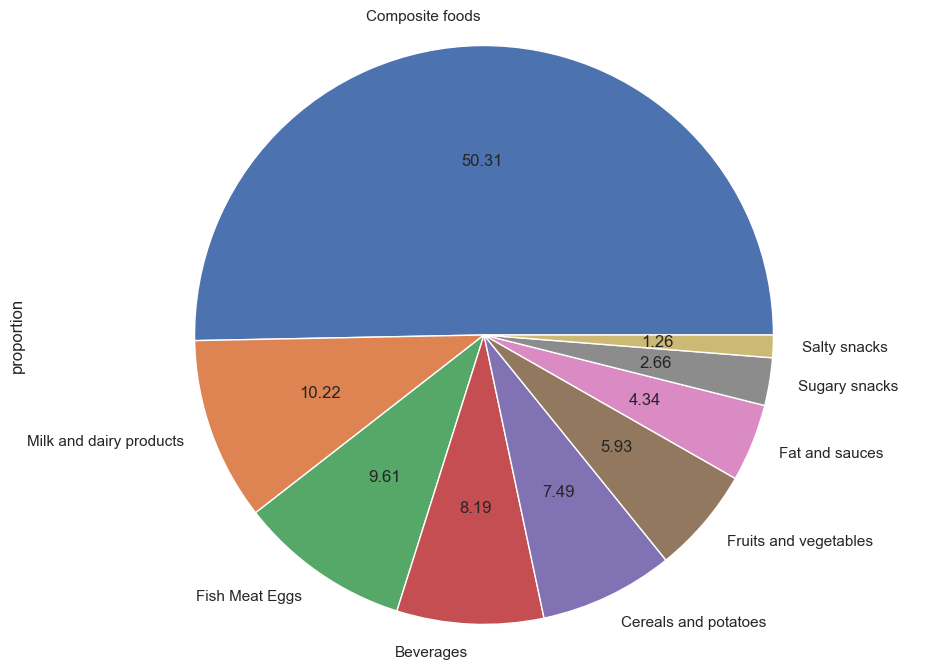

In [37]:
# Diagramme en secteurs
#sns.set(font_scale=1.2)
df['pnns_groups_1'].value_counts(normalize=True).plot(kind='pie', autopct='%.2f')

plt.axis('equal')
plt.show()



In [38]:
#colors = sns.color_palette('pastel')[0:5]

#plt.pie(df['pnns_groups_2'], colors = colors, autopct='%.0f%%')
#plt.show()

# Bi-variate

=> ajouter graphs num / num & cat/cat & num/cat

In [39]:
df.head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,6.7,12.41,One-dish meals,Composite foods
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,6.7,12.41,One-dish meals,Composite foods
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.40,Sweetened beverages,Beverages
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,6.7,12.41,One-dish meals,Composite foods
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,0.1,0.0,10.40,Sweetened beverages,Beverages


In [40]:
# cat / num

In [41]:
x = df['pnns_groups_1']
y = df['energy_100g']

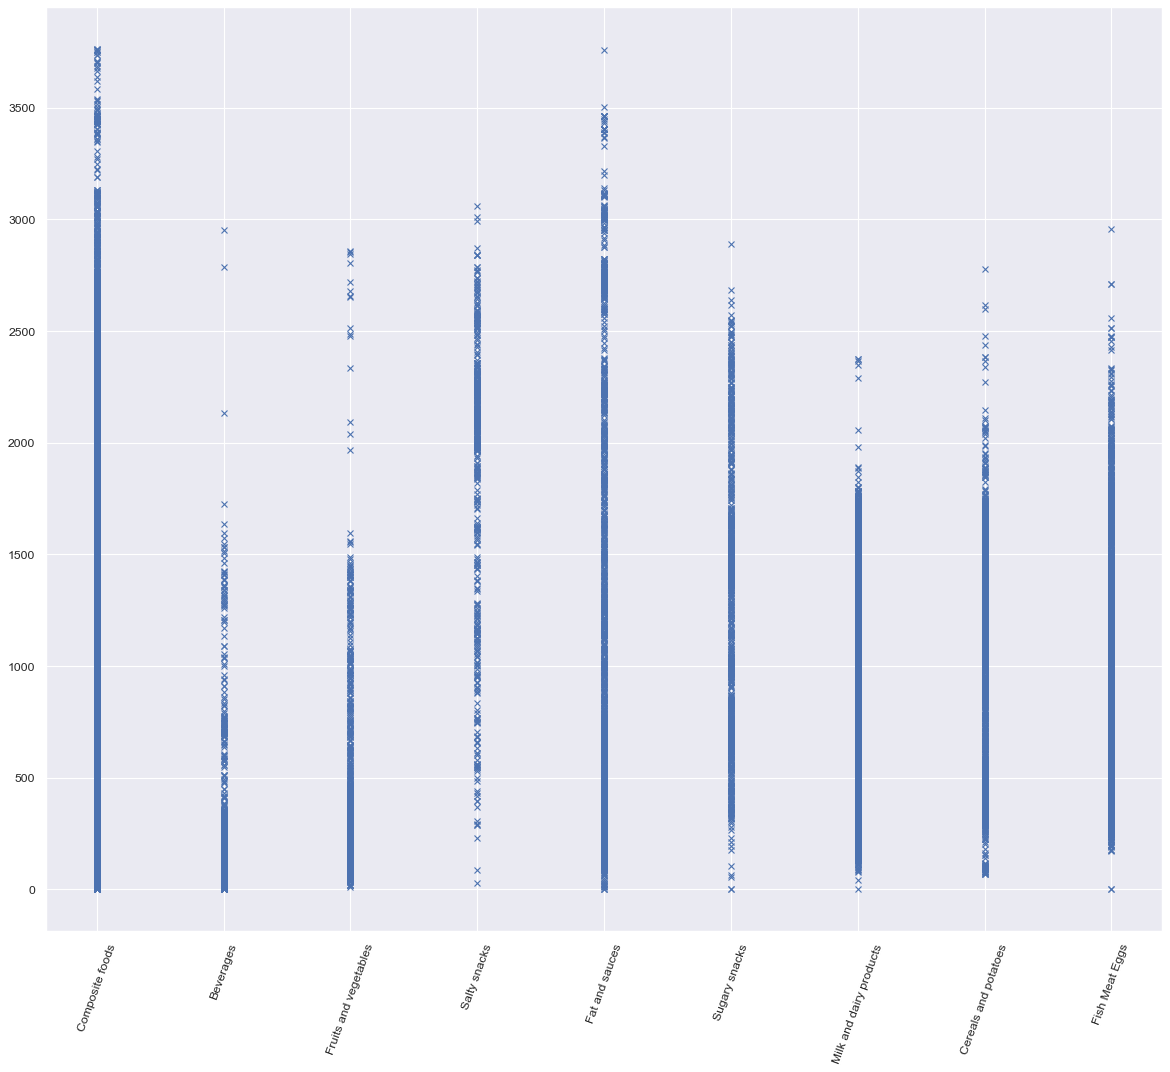

In [42]:
plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
plt.plot(x, y, 'x')
plt.show()

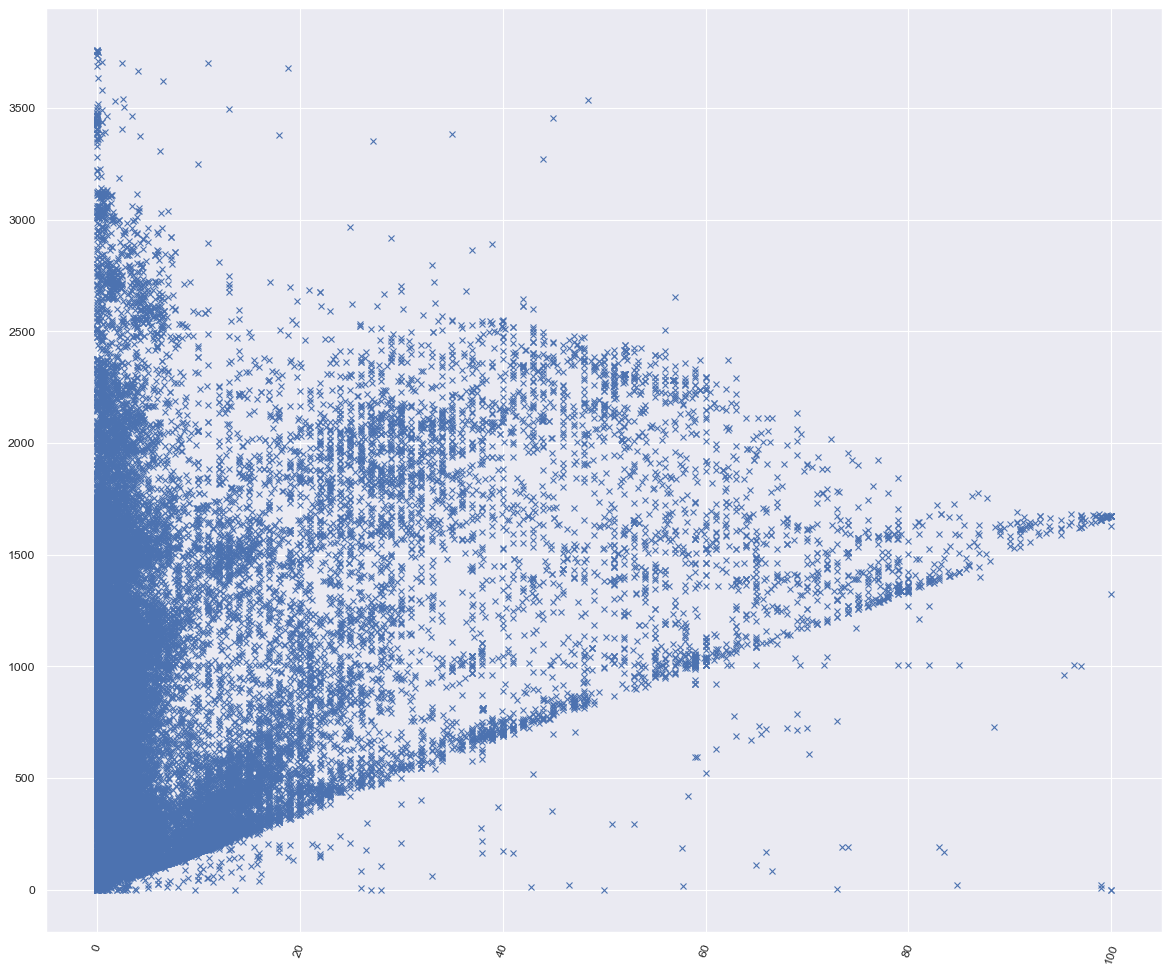

In [43]:
# num / num

plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
x = df['sugars_100g']
y = df['energy_100g']
plt.plot(x,y, 'x')
plt.show()
# titres
#taille

# Multi-variate


## Correlation Matrix

In [44]:
df[num_cols].corr()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
nutrition-score-fr_100g,1.000000,0.226986,0.592709,0.226864,0.219780,0.284358,0.602761,-0.079502,0.409492,-0.118056
proteins_100g,0.226986,1.000000,0.321107,0.203113,0.195440,-0.250295,0.234909,0.076308,0.216380,-0.060207
energy_100g,0.592709,0.321107,1.000000,0.074333,0.070353,0.222456,0.539640,0.179008,0.487555,0.269506
salt_100g,0.226864,0.203113,0.074333,1.000000,0.967725,-0.117054,0.063638,-0.030393,0.133777,-0.100206
sodium_100g,0.219780,0.195440,0.070353,0.967725,1.000000,-0.113988,0.060887,-0.029976,0.128532,-0.098050
sugars_100g,0.284358,-0.250295,0.222456,-0.117054,-0.113988,1.000000,0.019373,0.008655,-0.137591,0.074307
saturated-fat_100g,0.602761,0.234909,0.539640,0.063638,0.060887,0.019373,1.000000,-0.080511,0.424723,-0.149467
fiber_100g,-0.079502,0.076308,0.179008,-0.030393,-0.029976,0.008655,-0.080511,1.000000,-0.064850,0.207501
fat_100g,0.409492,0.216380,0.487555,0.133777,0.128532,-0.137591,0.424723,-0.064850,1.000000,-0.190468
carbohydrates_100g,-0.118056,-0.060207,0.269506,-0.100206,-0.098050,0.074307,-0.149467,0.207501,-0.190468,1.000000


Text(0.5, 1.0, 'Matrice de corrélation de Pearson entre les variables numériques')

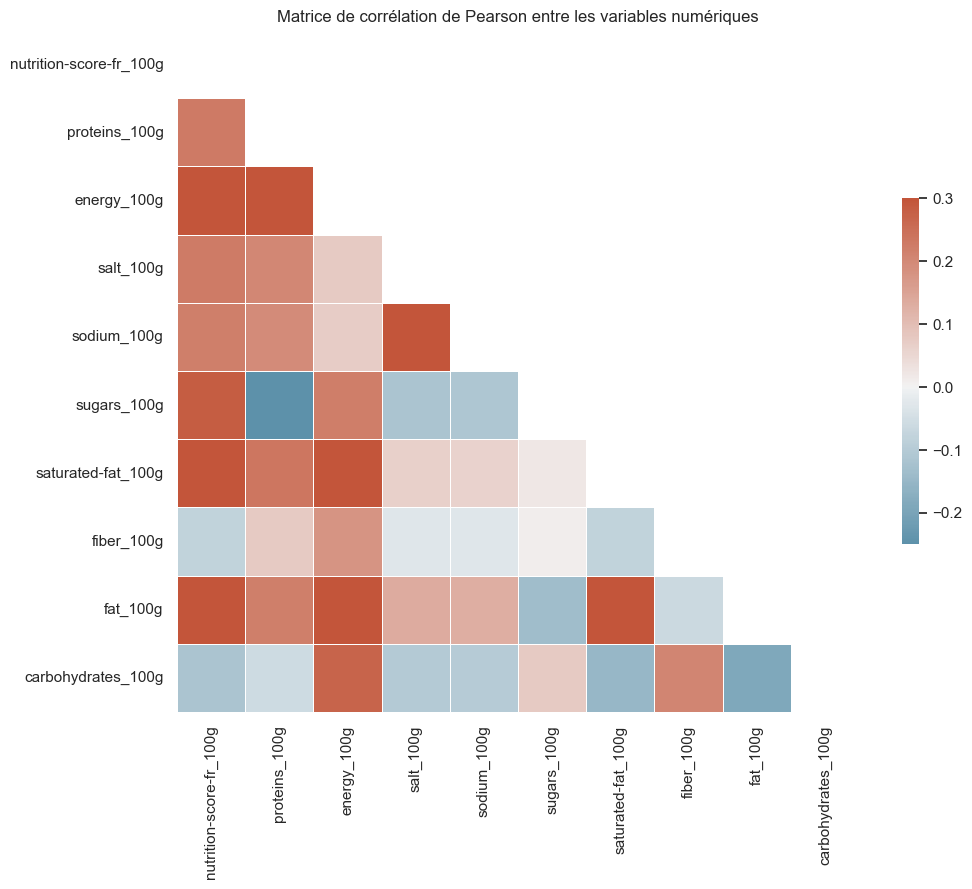

In [45]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = df[num_cols].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})\
   .set_title('Matrice de corrélation de Pearson entre les variables numériques')

On peut retirer du tableau les informations suivantes :

- **fat_100g** et **saturated-fat_100g** sont fortement corrélés
- **energy-kcal_100g** : forte corrélation avec :
  - fat_100g
  - saturated-fat_100g
  - carbohydrates_100g
  - proteins_100g
- **sodium_100g** et **salt_100g** sont fortement corrélés
- **sugars_100g** sont corrélés avec **carbohydrates_100g**

## Hierarchical clustering / CHA (Classification Hiérarchique Ascendante)

In [46]:
# Sur le P3, j'ai rajouté ce matin un CHA pour voir plus facilement les relations 
# entre les différents éléments numériques

In [47]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['nutrition-score-fr_100g', 'proteins_100g', 'energy_100g', 'salt_100g',
       'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g'],
      dtype='object')

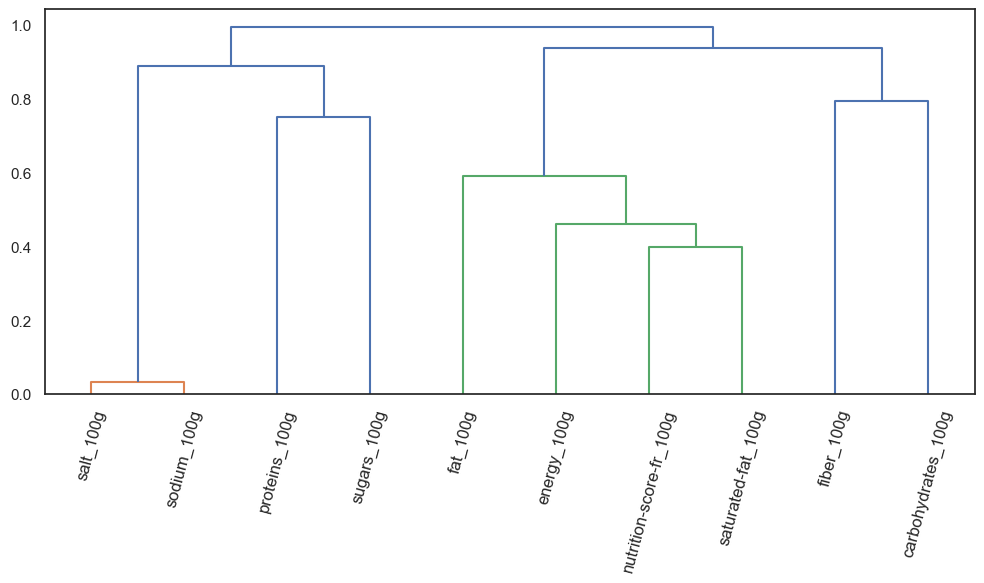

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

corr = df[num_cols].corr()

plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(corr)
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, 
           labels=num_cols, 
           orientation='top', 
           leaf_rotation=75
          );

# Multi-variate analysis

##  Analyse de la variance (ANOVA)

In [49]:
# normalisation / régularisation skewness avant Anova : utiliser le LOG

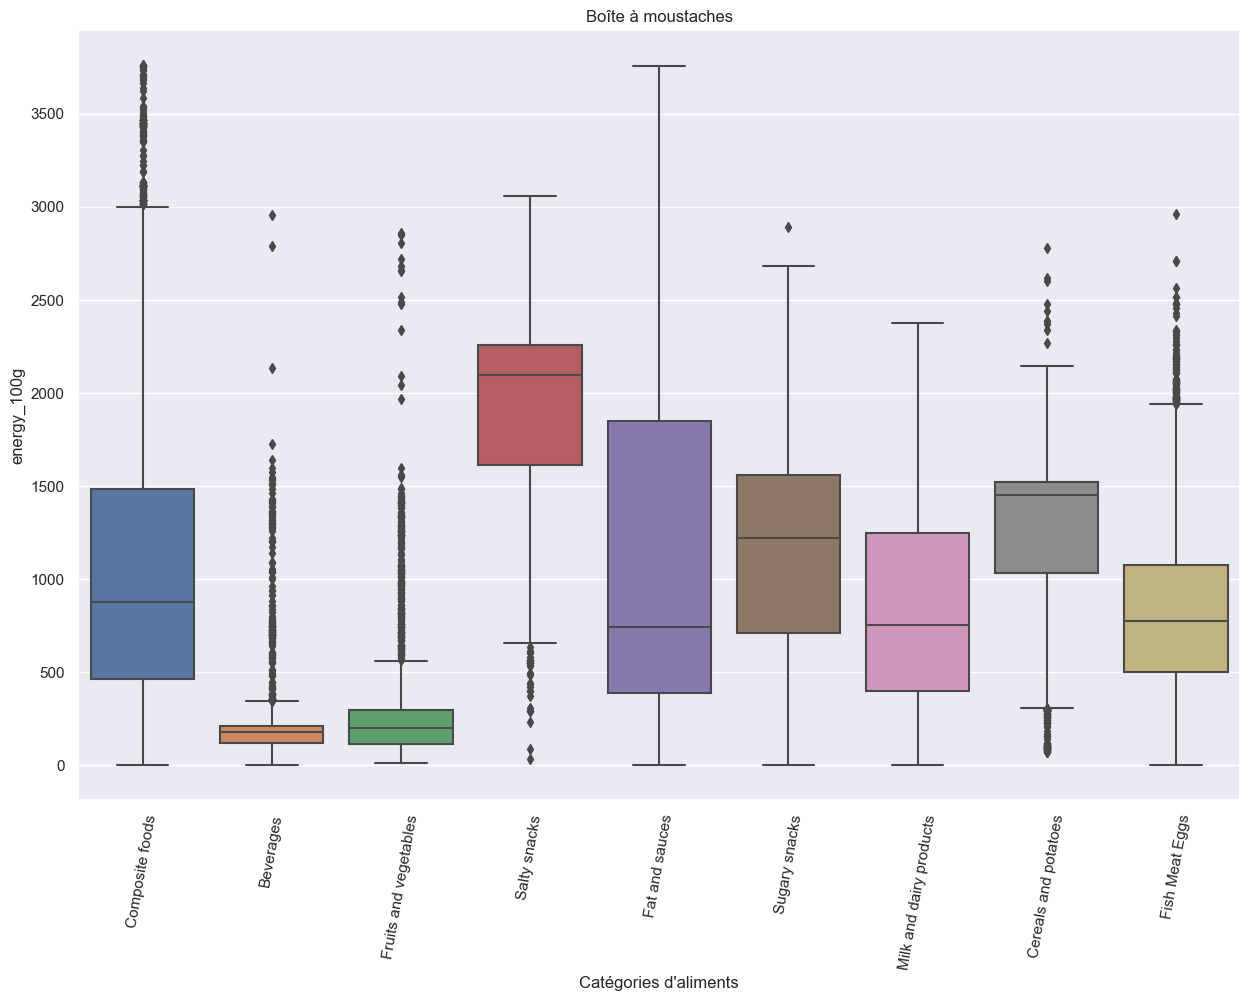

In [50]:
sns.set()
plt.figure(figsize = (15, 10))
plt.xticks(rotation=80)
ax = sns.boxplot(x='pnns_groups_1', y='energy_100g', data=df)
plt.xlabel("Catégories d'aliments")
plt.ylabel('energy_100g')
plt.title('Boîte à moustaches')
plt.show()

Les 12 catégories semblent différentes, il faut maintenant voir si les écarts sont significatifs ou pas grâce à l'ANOVA

=>  interpreting OLS summary results :

- [link1](https://statisticsbyjim.com/regression/interpret-coefficients-p-values-regression/)
- [link2](https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/)
- [link3](https://jyotiyadav99111.medium.com/statistics-how-should-i-interpret-results-of-ols-3bde1ebeec01)



In [51]:
# standard scale before anova ?

In [52]:
anova_category_nrj = smf.ols('energy_100g~pnns_groups_1', data=df).fit()
print(anova_category_nrj.summary())

                            OLS Regression Results                            
Dep. Variable:            energy_100g   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     1614.
Date:                Mon, 04 Mar 2024   Prob (F-statistic):               0.00
Time:                        15:39:42   Log-Likelihood:            -3.6055e+05
No. Observations:               46254   AIC:                         7.211e+05
Df Residuals:                   46245   BIC:                         7.212e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Tableau de l'analyse de la variance :

In [53]:
sm.stats.anova_lm(anova_category_nrj, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,4.460984e+09,8.0,1614.322256,0.0
Residual,1.597406e+10,46245.0,NaN,NaN


In [54]:
anova_category_fat = smf.ols('fat_100g~pnns_groups_1', data=df).fit()
print(anova_category_fat.summary())

                            OLS Regression Results                            
Dep. Variable:               fat_100g   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     2257.
Date:                Mon, 04 Mar 2024   Prob (F-statistic):               0.00
Time:                        15:39:42   Log-Likelihood:            -1.6582e+05
No. Observations:               46254   AIC:                         3.317e+05
Df Residuals:                   46245   BIC:                         3.317e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Tableau d'analyse de la variance :

In [55]:
sm.stats.anova_lm(anova_category_fat, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,1.374511e+06,8.0,2256.748046,0.0
Residual,3.520789e+06,46245.0,NaN,NaN


In [56]:
anova_category2_nrj = smf.ols('salt_100g~pnns_groups_1', data=df).fit()
print(anova_category2_nrj.summary())

                            OLS Regression Results                            
Dep. Variable:              salt_100g   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     377.2
Date:                Mon, 04 Mar 2024   Prob (F-statistic):               0.00
Time:                        15:39:43   Log-Likelihood:            -1.0103e+05
No. Observations:               46254   AIC:                         2.021e+05
Df Residuals:                   46245   BIC:                         2.022e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [57]:
sm.stats.anova_lm(anova_category2_nrj, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,13948.420420,8.0,377.195745,0.0
Residual,213763.248768,46245.0,NaN,NaN


## PCA

In [58]:
#features = df.columns[df.dtypes == 'float64']
#features

In [59]:
#features.size

In [60]:
# toutes features
# transformer variables categorielles en nombres (ex : ordinalEncoder +++ / OneHotEncoder)


In [61]:
df.columns

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [62]:
df_nutri = df[['nutrition-score-fr_100g', 'nutrition_grade_fr']].copy()

In [63]:
dfc = df.copy()

In [64]:
dfc.drop(columns=['product_name', 'code', 'nutrition-score-fr_100g', 'nutrition_grade_fr'], inplace=True)

In [65]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46254 entries, 0 to 46253
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   proteins_100g       46254 non-null  float64
 1   energy_100g         46254 non-null  float64
 2   salt_100g           46254 non-null  float64
 3   sodium_100g         46254 non-null  float64
 4   sugars_100g         46254 non-null  float64
 5   saturated-fat_100g  46254 non-null  float64
 6   fiber_100g          46254 non-null  float64
 7   fat_100g            46254 non-null  float64
 8   carbohydrates_100g  46254 non-null  float64
 9   pnns_groups_2       46254 non-null  object 
 10  pnns_groups_1       46254 non-null  object 
dtypes: float64(9), object(2)
memory usage: 3.9+ MB


In [66]:
energy_cols

['energy_100g']

In [67]:
## enlever product_name & code

In [68]:
dfc[energy_cols].head()

,energy_100g
0,1753.0
1,2406.0
2,177.0
3,1079.0
4,177.0


In [69]:
# encoding categories
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
dfc[energy_cols] = enc.fit_transform(dfc[energy_cols])

In [70]:
dfc.head()

,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,0.6,1938.0,0.0100,0.003937,87.7,0.8,0.9,6.7,12.41,One-dish meals,Composite foods
1,9.5,2391.0,0.0030,0.001181,50.3,2.9,3.9,6.7,12.41,One-dish meals,Composite foods
2,0.0,247.0,0.0254,0.010000,10.4,0.0,0.0,0.0,10.40,Sweetened beverages,Beverages
3,7.5,1237.0,0.8000,0.314961,1.0,11.0,1.4,6.7,12.41,One-dish meals,Composite foods
4,0.0,247.0,0.1000,0.039370,10.4,0.0,0.1,0.0,10.40,Sweetened beverages,Beverages


In [71]:
dfc.columns

Index(['proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'fiber_100g', 'fat_100g',
       'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [72]:
def clean_data(data, select_X=None, impute=False, std=False): 
    """Returns dataframe with selected, imputed 
       and standardized features
    
    Input
          data: dataframe
          select_X: list of feature names to be selected (string)
          impute: If True impute np.nan with mean
          std: If True standardize data
          
    Return
        dataframe: data with selected, imputed 
                   and standardized features    
    """
    
    # (i.) select features
    if select_X is not None:
        data = data.filter(select_X, axis='columns')
        print("\t>>> Selected features: {}".format(select_X))
    else:
        # store column names
        select_X = list(data.columns)
    
    # (ii.) impute with mean 
    if impute:
        imp = SimpleImputer()
        data = imp.fit_transform(data)
        print("\t>>> Imputed missings")
    
    # (iii.) standardize 
    if std:
        std_scaler = StandardScaler()
        data = std_scaler.fit_transform(data)
        print("\t>>> Standardized data")
    
    return pd.DataFrame(data, columns=select_X)

#  (iv.) select relevant features 
selected_features = [
    'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'fiber_100g', 'fat_100g',
       'carbohydrates_100g'
    #'energy_kcal_100g', 'fat_100g','saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
    #'proteins_100g', 'salt_100g', 'sodium_100g'
            ]

#selected_features = [num_cols] + [energy_cols] 
#+ ['nutriscore']
# (v.) select features, impute missings and standardize
X_std = clean_data(dfc, selected_features, impute=False, std=True)

	>>> Selected features: ['proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g', 'fat_100g', 'carbohydrates_100g']
	>>> Standardized data


In [73]:
#selected_features = ['pnns_groups_1', 'pnns_groups_2', 'energy_kcal_100g', 'fat_100g',
#       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
#       'proteins_100g', 'salt_100g', 'sodium_100g']

In [74]:
X_std.head()

,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
0,-0.905215,1.385824,-0.459805,-0.446205,5.592371,-0.489541,-0.229637,-0.157547,-0.171735
1,0.183859,2.067475,-0.462960,-0.449258,2.954683,-0.192584,0.595524,-0.157547,-0.171735
2,-0.978636,-1.158706,-0.452864,-0.439487,0.140678,-0.602668,-0.477185,-0.808815,-0.290969
3,-0.060876,0.330995,-0.103757,-0.101595,-0.522271,0.952821,-0.092110,-0.157547,-0.171735
4,-0.978636,-1.158706,-0.419243,-0.406945,0.140678,-0.602668,-0.449679,-0.808815,-0.290969


In [75]:
X_std.shape[1]

9

In [76]:
# Initialize PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_std)

PCA()

In [77]:
# Get basic info
n_components = len(pca.explained_variance_ratio_)
explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

Résumé PCA
Total: 9 composants
----------------------------------------
Moyenne de la variance expliquée : 0.111
----------------------------------------
   explained variance  cumulative
1            0.268732    0.268732
2            0.203349    0.472081
3            0.154272    0.626353
4            0.126208    0.752561
5            0.087448    0.840009
6            0.077796    0.917805
7            0.059282    0.977087
8            0.019331    0.996419
9            0.003581    1.000000
----------------------------------------


Le 1er composant représente 25% de la variance.

Si l'on veut réduire les dimensions existantes et retenir 91% de la variance originale, on peut rester sur 6 composants.


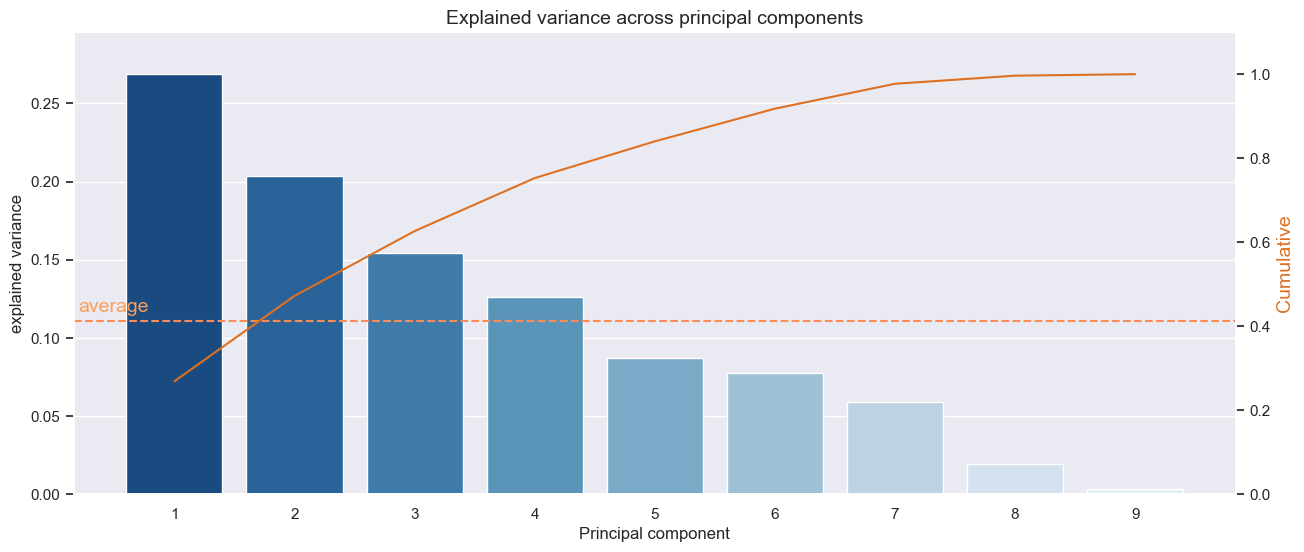

In [78]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

In [79]:
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.get_feature_names_out

#get_feature_names_out(input_features=None)[source]

In [80]:
# test PCA with non-scaled data..

In [81]:
X_std_2 = clean_data(dfc, selected_features, impute=False, std=False)

	>>> Selected features: ['proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g', 'fat_100g', 'carbohydrates_100g']


In [82]:
pca2 = PCA()
pca2.fit(X_std_2)

PCA()

In [83]:
# Get basic info
n_components = len(pca2.explained_variance_ratio_)
explained_variance = pca2.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

Résumé PCA
Total: 9 composants
----------------------------------------
Moyenne de la variance expliquée : 0.111
----------------------------------------
   explained variance  cumulative
1        9.985448e-01    0.998545
2        6.525967e-04    0.999197
3        4.625053e-04    0.999660
4        1.441724e-04    0.999804
5        9.009853e-05    0.999894
6        6.766477e-05    0.999962
7        2.606419e-05    0.999988
8        1.201394e-05    1.000000
9        1.011104e-07    1.000000
----------------------------------------


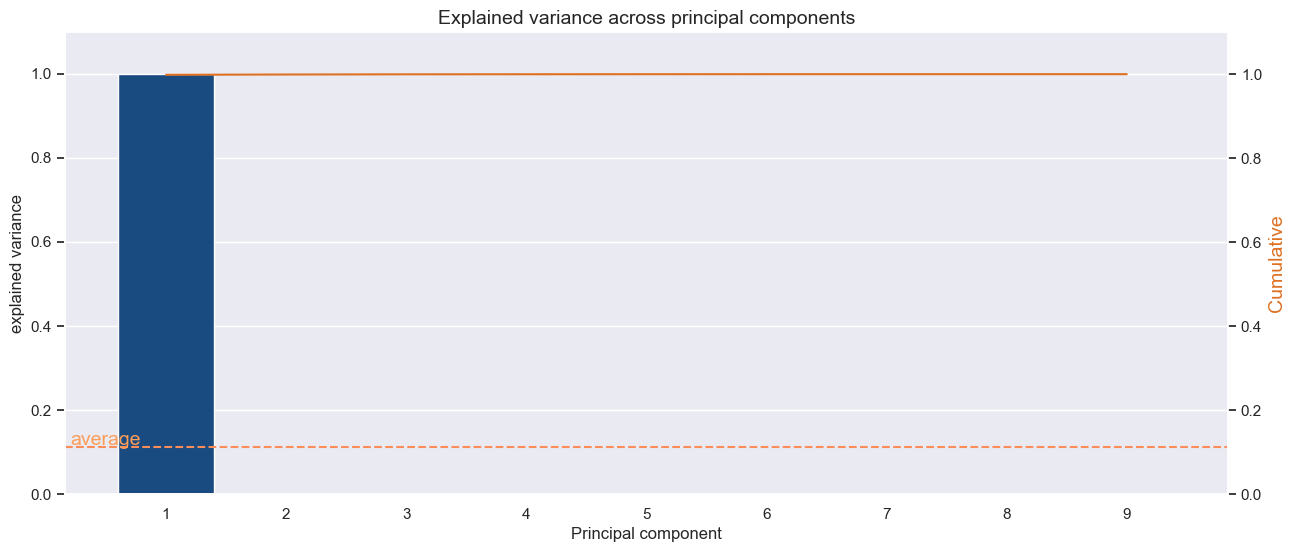

In [84]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

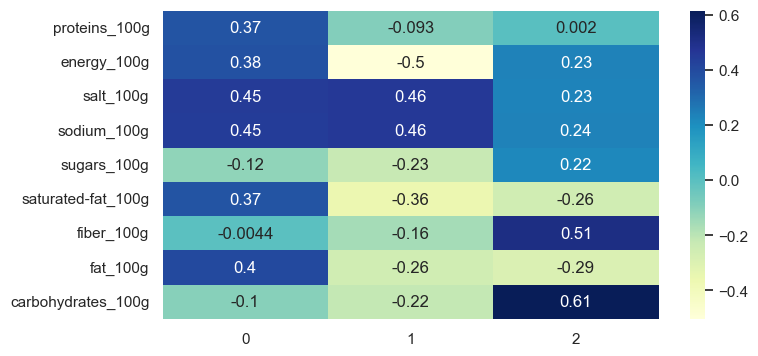

In [85]:
# check factor loading matrix
df_c = pd.DataFrame(pca.components_, columns=selected_features).T

# adjust y-axis size dynamically
size_yaxis = round(X_std.shape[1] * 0.5)
fig, ax = plt.subplots(figsize=(8,size_yaxis))# plot the first top_pc components
top_pc = 3
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

Factor Loadings of 1st PC

Top 5 highest
----------------------------------------
salt_100g             0.450814
sodium_100g           0.447384
fat_100g              0.402620
energy_100g           0.375739
saturated-fat_100g    0.368534
Name: 0, dtype: float64 

Top 5 lowest
----------------------------------------
sugars_100g          -0.115506
carbohydrates_100g   -0.099737
fiber_100g           -0.004433
proteins_100g         0.366341
saturated-fat_100g    0.368534
Name: 0, dtype: float64


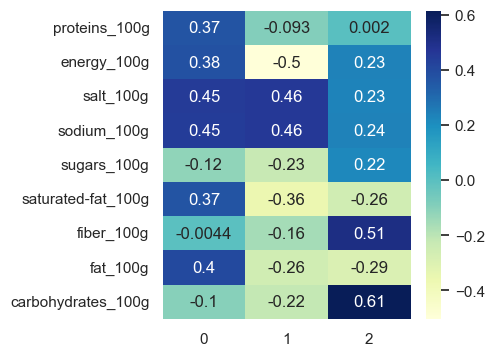

In [86]:
top_k = 5
print("Factor Loadings of 1st PC")
print('='*40,'\n')
print('Top {} highest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values(ascending=False)[:top_k], '\n')

print('Top {} lowest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values()[:top_k])

# Plot heatmap
size_xaxis = round(top_pc * 1.5)
size_yaxis = round(n_components * 0.5)

fig, ax = plt.subplots(figsize=(size_xaxis,size_yaxis))
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

### Cercle de correlation

In [87]:
# https://stackoverflow.com/questions/37815987/plot-a-correlation-circle-in-python

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,6.7,12.41,One-dish meals,Composite foods,850.209169,9.500542,75.650464,-2.019395,6.963155,-10.595374,3.329998,-2.042147,0.920808,0.001955
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,6.7,12.41,One-dish meals,Composite foods,1503.012527,0.059920,38.132983,9.114159,-3.828142,-11.547729,0.524506,-1.206902,-0.338445,0.004501
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.40,Sweetened beverages,Beverages,-726.068721,1.350767,7.526349,-1.303227,-1.743726,5.404587,-6.531423,0.350289,-1.983395,-0.000075
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,6.7,12.41,One-dish meals,Composite foods,175.961700,-5.661423,-5.467274,2.467782,-3.961524,8.087254,-1.968432,0.574701,-0.934710,-0.000213
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,0.1,0.0,10.40,Sweetened beverages,Beverages,-726.068602,1.352975,7.523053,-1.294776,-1.744454,5.391993,-6.538519,0.450294,-1.905100,-0.000346


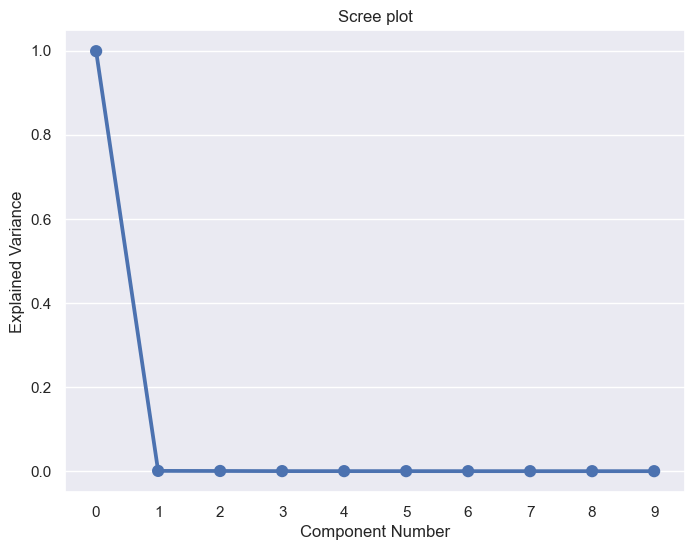

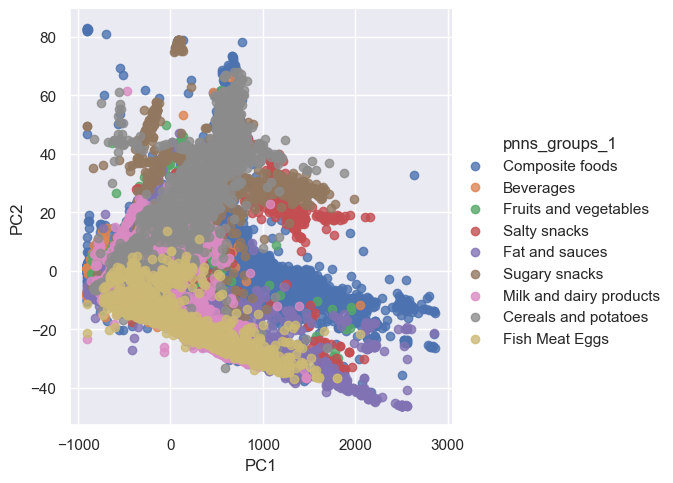

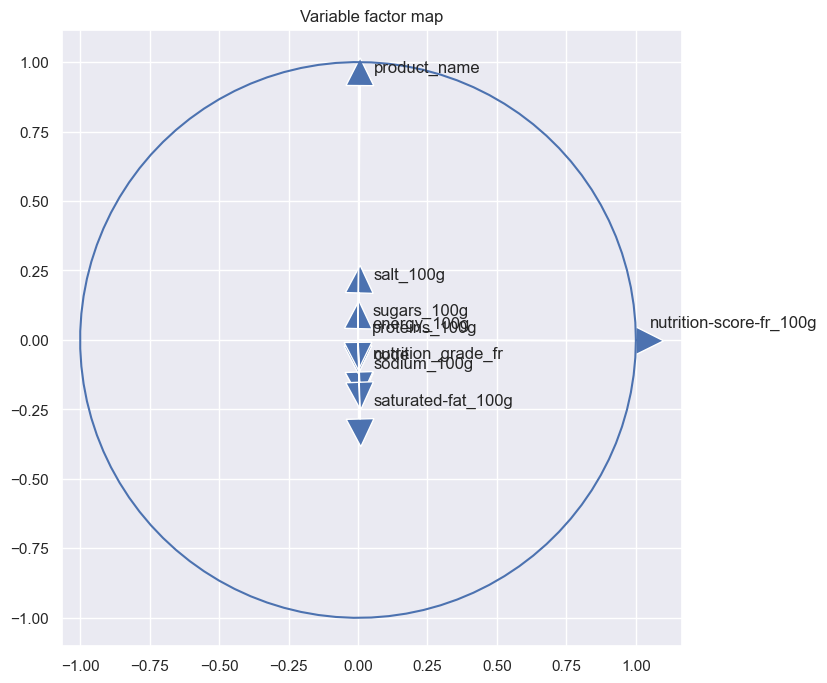

In [88]:
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
 
#df = sns.load_dataset('iris')
 
n_components = len(num_cols)
 
# Do the PCA.
pca = PCA(n_components=n_components)
reduced = pca.fit_transform(df[num_cols])

# Append the principle components for each entry to the dataframe
#for i in range(0, n_components):
for i in range(pca.components_.shape[1]):
    df['PC' + str(i + 1)] = reduced[:, i]

display(df.head())

# Do a scree plot
ind = np.arange(0, n_components)
(fig, ax) = plt.subplots(figsize=(8, 6))
sns.pointplot(x=ind, y=pca.explained_variance_ratio_)
ax.set_title('Scree plot')
ax.set_xticks(ind)
ax.set_xticklabels(ind)
ax.set_xlabel('Component Number')
ax.set_ylabel('Explained Variance')
plt.show()

# Show the points in terms of the first two PCs
g = sns.lmplot(data=df,
               x='PC1',
               y='PC2',
               hue='pnns_groups_1',
               fit_reg=False,
               scatter=True
               #,size=7
              )

plt.show()

# Plot a variable factor map for the first two dimensions.
(fig, ax) = plt.subplots(figsize=(8, 8))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.1,
             head_length=0.1)

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             df.columns.values[i])


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
ax.set_title('Variable factor map')
plt.show()

In [89]:
# needing target aka nutriscore ?

In [90]:
def circleOfCorrelations(pc_infos, ebouli):
    plt.Circle((0,0),radius=10, color='g', fill=False)
    circle1=plt.Circle((0,0),radius=1, color='g', fill=False)
    fig = plt.gcf()
    fig.gca().add_artist(circle1)
    for idx in range(len(pc_infos["PC-0"])):
        x = pc_infos["PC-0"][idx]
        y = pc_infos["PC-1"][idx]
        plt.plot([0.0,x],[0.0,y],'k-')
        plt.plot(x, y, 'rx')
        plt.annotate(pc_infos.index[idx], xy=(x,y))
    plt.xlabel("PC-0 (%s%%)" % str(ebouli[0])[:4].lstrip("0."))
    plt.ylabel("PC-1 (%s%%)" % str(ebouli[1])[:4].lstrip("0."))
    plt.xlim((-1,1))
    plt.ylim((-1,1))
    plt.title("Circle of Correlations")